<a href="https://colab.research.google.com/github/Md-Salman-Rahman339/AI-ML/blob/main/Copy_of_AI_ML_Assignment_3_Module_19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 AI/ML Assignment 3
## Supervised Learning Models in Practice

**Total Marks: 100**  
**Submission Format:** Single Jupyter Notebook (`.ipynb`)

---
## 📌 General Instructions (Read Carefully)

- This assignment covers **Modules 13–18**.
- Use **Python and scikit-learn only**.
- Do NOT use AutoML, deep learning, or external ML libraries.
- Fix `random_state=42` wherever applicable.
- Plots must be labeled and readable.
- Do not delete or rename cells.

***Classification Dataset:*** https://www.kaggle.com/datasets/taweilo/loan-approval-classification-data/data

***Regresssion Dataset:*** https://www.kaggle.com/datasets/mirichoi0218/insurance

## 🔧 TODO 0: Environment Setup (5 Marks)
**Marks Breakdown:**
- Correct imports (3)
- Clean setup, no unused imports (2)


In [2]:
# TODO: Import all necessary libraries here
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

np.random.seed(42)

plt.rcParams['figure.figsize']=(8,5)
plt.rcParams['axes.grid']=True
sns.set_style('darkgrid')


# 🔵 PART A: Regression Task (45 Marks)
You will work with the provided **regression dataset**.


## TODO A1: Dataset Loading and Understanding (5 Marks)
**You must:**
- Load the dataset
- Show shape and column names
- Identify target variable

**Marks:** Data loading (2), Explanation (3)


In [3]:
# TODO: Load regression dataset
df_regression=pd.read_csv('/content/insurance.csv')

print("Dataset Shape:",df_regression.shape)
print("\nColumn Names:")
print(df_regression.columns.to_list())
print("\nFirst 5 rows:")
df_regression.head()

Dataset Shape: (1338, 7)

Column Names:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

First 5 rows:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# Target Variable:
charges(medical insurance costs)
# Features:
age,sex,bmi,children,smoker,region

This dataset contain 1338 rows and 7 columns.We will predict insurance charges based on persons information

## TODO A2: Exploratory Data Analysis (EDA) (5 Marks)
**You must:**
- Show descriptive statistics
- Plot correlation heatmap
- Plot at least one feature vs target

**Marks:** Plots (3), Interpretation (2)


## Descriptive statistics:

In [4]:
# TODO: Perform EDA
print("Descriptive Statistics:")
print(df_regression.describe().T)
print("\nData types:")
print(df_regression.dtypes)
print("\nMissing Values:")
print(df_regression.isnull().sum())

Descriptive Statistics:
           count          mean           std        min         25%       50%  \
age       1338.0     39.207025     14.049960    18.0000    27.00000    39.000   
bmi       1338.0     30.663397      6.098187    15.9600    26.29625    30.400   
children  1338.0      1.094918      1.205493     0.0000     0.00000     1.000   
charges   1338.0  13270.422265  12110.011237  1121.8739  4740.28715  9382.033   

                   75%          max  
age          51.000000     64.00000  
bmi          34.693750     53.13000  
children      2.000000      5.00000  
charges   16639.912515  63770.42801  

Data types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

Missing Values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


# Plot correlation heatmap:

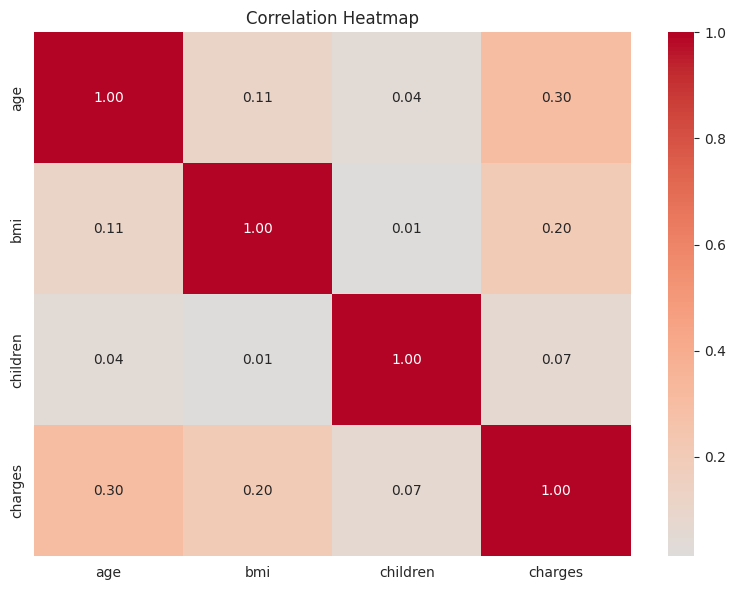

In [5]:
numeric_columns=df_regression.select_dtypes(include=[np.number]).columns
correlation=df_regression[numeric_columns].corr()
plt.figure(figsize=(8,6))
sns.heatmap(correlation,annot=True,cmap='coolwarm',fmt='.2f',center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# Plot at least one feature vs target:

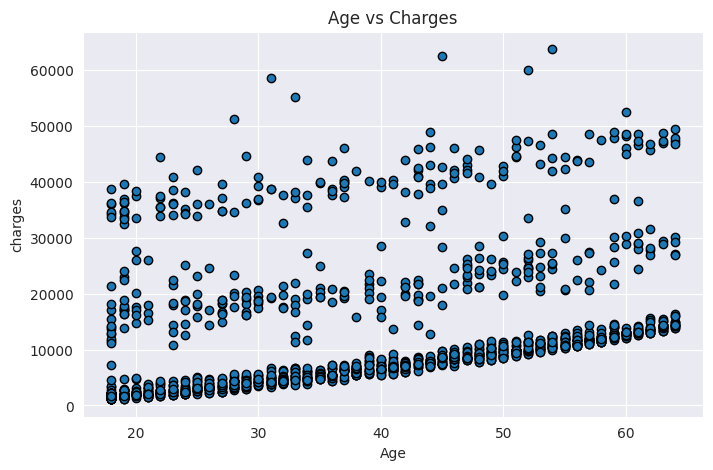

In [6]:
# Age vs Charges
plt.figure(figsize=(8,5))
plt.scatter(df_regression['age'],df_regression['charges'],edgecolors='k')
plt.xlabel('Age')
plt.ylabel('charges')
plt.title('Age vs Charges')
plt.grid(True)
plt.show()

# Smoker status vs Charges

<Figure size 700x500 with 0 Axes>

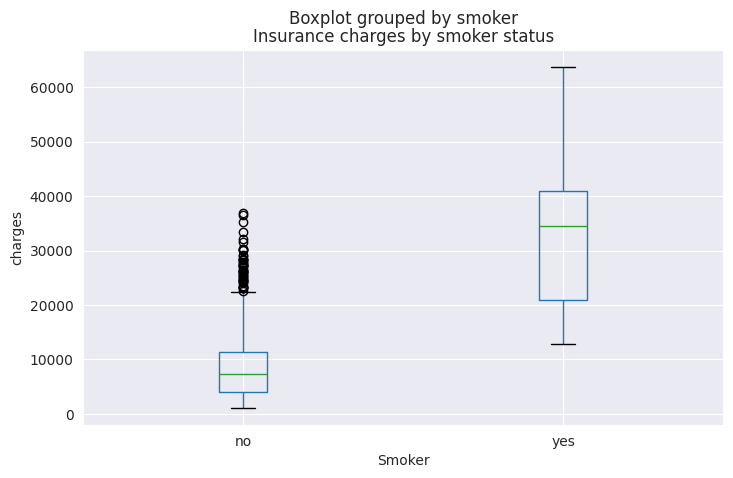

In [7]:

plt.figure(figsize=(7,5))
df_regression.boxplot(column='charges',by='smoker',grid=True)
plt.title('Insurance charges by smoker status')
plt.xlabel('Smoker')
plt.ylabel('charges')
plt.show()

# Observations:
1.No missing value in the dataset
2.Smokers has strong correlation with charges
3.Age and BMI shows us moderate positive correlation with charges
4.Smokers has higher insurance charges than non-smokers

## TODO A3: Feature Preparation (5 Marks)
**You must:**
- Train-test split
- Scaling (if applicable)

**Marks:** Correct split (3), Explanation (2)


In [9]:
# TODO: Prepare features
df_reg_encoded=df_regression.copy()

l_sex=LabelEncoder()
l_smoker=LabelEncoder()
l_region=LabelEncoder()

df_reg_encoded['sex']=l_sex.fit_transform(df_regression['sex'])
df_reg_encoded['smoker']=l_smoker.fit_transform(df_regression['smoker'])
df_reg_encoded['region']=l_region.fit_transform(df_regression['region'])

x=df_reg_encoded.drop('charges',axis=1)
y=df_reg_encoded['charges']

X_train,X_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42)

scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train)
X_test_reg_scaled = scaler_reg.transform(X_test)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)


Training set size: (1070, 6)
Test set size: (268, 6)


## TODO A4: Multiple Linear Regression (8 Marks)
**You must:**
- Train model
- Evaluate using RMSE, MAE, R²

**Marks:** Model (4), Metrics (4)


In [11]:
# TODO: Multiple Linear Regression
# Train model
model_reg=LinearRegression()
model_reg.fit(X_train_reg_scaled,y_train)
# Predictions
y_pred_train=model_reg.predict(X_train_reg_scaled)
y_pred_test=model_reg.predict(X_test_reg_scaled)

# Evaluate model
rmse=np.sqrt(mean_squared_error(y_test,y_pred_test))
mae=mean_absolute_error(y_test,y_pred_test)
r2=r2_score(y_test,y_pred_test)

print(f"RMSE:{rmse:.3f}")
print(f"MAE:{mae:.3f}")
print(f"R2:{r2:.3f}")

RMSE:5799.587
MAE:4186.509
R2:0.783


## TODO A5: Polynomial Regression (7 Marks)
**You must:**
- Apply polynomial features
- Compare with linear regression

**Marks:** Implementation (4), Comparison (3)


# Apply polynomial features:

In [13]:
# TODO: Polynomial Regression
p_pipeline=Pipeline([
    ('poly',PolynomialFeatures(degree=2)),
    ('model',LinearRegression())
])
p_pipeline.fit(X_train_reg_scaled,y_train)

y_pred_test_p=p_pipeline.predict(X_test_reg_scaled)

# Evaluate model
p_rmse=np.sqrt(mean_squared_error(y_test,y_pred_test_p))
p_mae=mean_absolute_error(y_test,y_pred_test_p)
p_r2=r2_score(y_test,y_pred_test_p)

print(f"RMSE:{p_rmse:.3f}")
print(f"MAE:{p_mae:.3f}")
print(f"R2:{p_r2:.3f}")


RMSE:4531.072
MAE:2730.316
R2:0.868


## Compare with linear regression

In [14]:
compare_df=pd.DataFrame({
    'Model':['Linear Regression','Polynomial Regression'],
    'RMSE':[rmse,p_rmse],
    'MAE':[mae,p_mae],
    'R**2':[r2,p_r2]
})
print(compare_df.to_string(index=False))

                Model        RMSE         MAE     R**2
    Linear Regression 5799.587091 4186.508898 0.783346
Polynomial Regression 4531.071501 2730.315582 0.867757


Polynomial regression perform better than linear regression

## TODO A6: Support Vector Regression (7 Marks)
**You must:**
- Train SVR (RBF kernel)
- Evaluate performance
- Justify kernel choice

**Marks:** Model (4), Justification (3)


In [15]:
# TODO: Support Vector Regression
svr_model=SVR(kernel='rbf',C=10.0,gamma='scale')
svr_model.fit(X_train_reg_scaled,y_train)

y_pred_test_svr=svr_model.predict(X_test_reg_scaled)
svr_rmse=np.sqrt(mean_squared_error(y_test,y_pred_test_svr))
svr_mae=mean_absolute_error(y_test,y_pred_test_svr)
svr_r2=r2_score(y_test,y_pred_test_svr)

print(f"RMSE:{svr_rmse:.3f}")
print(f"MAE:{svr_mae:.3f}")
print(f"R2:{svr_r2:.3f}")


RMSE:12579.365
MAE:8209.996
R2:-0.019


# Justify kernel choice:

1.relationship of features and charges is non-linear.
2.RBF Kernal can learn complex pattern compared to linear kernal
3.when data is properly scaled it performs better
4.it is also suitable for datasets of medium size like our dataset


## TODO A7: Random Forest Regressor (8 Marks)
**You must:**
- Train Random Forest
- Evaluate model

**Marks:** Model (4), Evaluation (4)


In [17]:
# TODO: Random Forest Regressor

rf_model_reg = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)
rf_model_reg.fit(X_train_reg_scaled, y_train)


y_pred_test_RF= rf_model_reg.predict(X_test_reg_scaled)

RF_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test_RF))
RF_mae = mean_absolute_error(y_test, y_pred_test_RF)
RF_r2= r2_score(y_test,y_pred_test_RF)

print("Random Forest Regressor Results:")
print(f"RMSE: ${RF_rmse:.4f}")
print(f"MAE:  ${RF_mae:.4f}")
print(f"R²:   {RF_r2:.4f}")

Random Forest Regressor Results:
RMSE: $4586.6274
MAE:  $2517.1125
R²:   0.8645


# Compare all model:

In [18]:
compare_df=pd.DataFrame({
    'Model':['Linear Regression','Polynomial Regression','SVR(RBF)','Random Forest'],
    'RMSE':[rmse,p_rmse,svr_rmse,RF_rmse],
    'MAE':[mae,p_mae,svr_rmse,RF_rmse],
    'R**2':[r2,p_r2,svr_rmse,RF_r2]
})
print(compare_df.to_string(index=False))

                Model         RMSE          MAE         R**2
    Linear Regression  5799.587091  4186.508898     0.783346
Polynomial Regression  4531.071501  2730.315582     0.867757
             SVR(RBF) 12579.364950 12579.364950 12579.364950
        Random Forest  4586.627443  4586.627443     0.864494


lowest RMSE and High R**2 best model is Polynomial Regression

# 🟠 PART B: Classification Task (45 Marks)
You will work with the provided **classification dataset**.


## TODO B1: Dataset Understanding (5 Marks)
**You must:**
- Load dataset
- Show class distribution
- Comment on imbalance

**Marks:** Analysis (3), Explanation (2)


In [19]:
# TODO: Load classification dataset
df_class=pd.read_csv('/content/loan_data.csv')
print("Dataset Shape:",df_class.shape)
print("\nColumn Names:")
print(df_class.columns.to_list())
print("\nFirst 5 rows:")
df_class.head()



Dataset Shape: (45000, 14)

Column Names:
['person_age', 'person_gender', 'person_education', 'person_income', 'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'previous_loan_defaults_on_file', 'loan_status']

First 5 rows:


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


# Class Distribution:

In [20]:
print("\nClass Distribution:")
print(df_class['loan_status'].value_counts())
print("\nClass Distribution (%):")
print(df_class['loan_status'].value_counts(normalize=True)*100)


Class Distribution:
loan_status
0    35000
1    10000
Name: count, dtype: int64

Class Distribution (%):
loan_status
0    77.777778
1    22.222222
Name: proportion, dtype: float64


Target Variable:loan_status(wheather loan is approve or not)

1.Understanding this distribution we can build better model to predict our loan is approved or not.
2.the target variable loan_status tells us loan is approved or not
3.wed can from the distribution 77.78% of the loan is not approved and 22.22% of the loan is approved

## TODO B2: Exploratory Data Analysis (5 Marks)
**You must:**
- Plot class counts
- Plot at least one feature vs class

**Marks:** Plots (5),


# Plot class counts

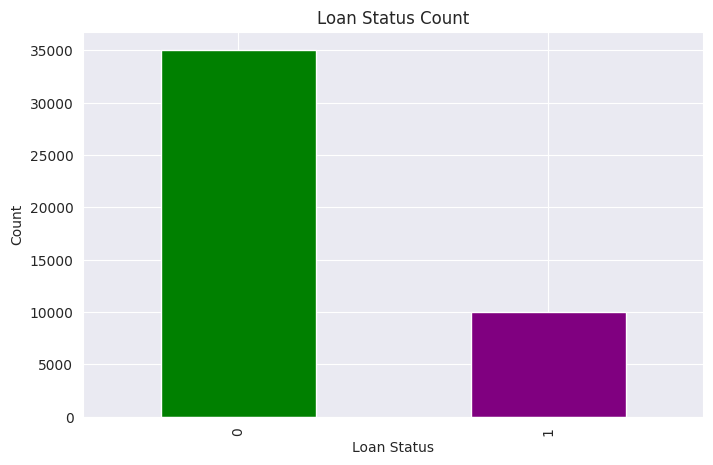

In [22]:
# TODO: Classification EDA
plt.figure(figsize=(8,5))
df_class['loan_status'].value_counts().plot(kind='bar',color=['green','purple'])
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.title('Loan Status Count')
plt.grid(True)
plt.show()

# Plot at least one feature vs class

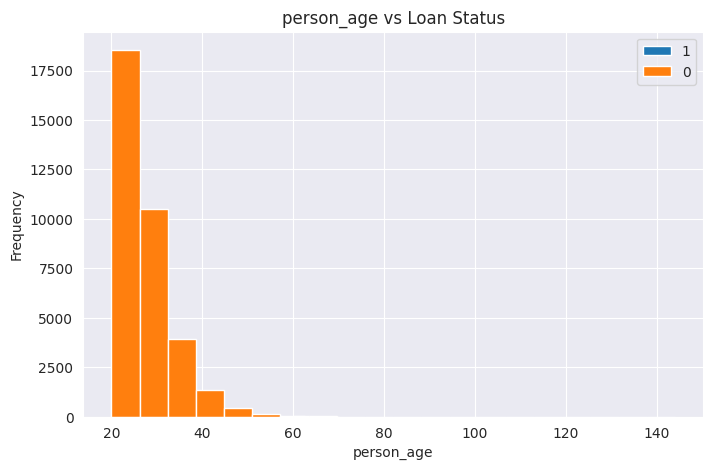

In [24]:
numeric_columns=df_class.select_dtypes(include=[np.number]).columns

feature =numeric_columns[0]

plt.figure(figsize=(8,5))
for status in df_class['loan_status'].unique():
    data=df_class[df_class['loan_status']==status][feature]
    plt.hist(data,bins=20,label=status)

plt.xlabel(feature)
plt.ylabel("Frequency")
plt.title(f"{feature} vs Loan Status")
plt.legend()
plt.grid(True)
plt.show()


## TODO B3: Feature Preparation (5 Marks)
**You must:**
- Encoding (if needed)
- Scaling
- Train-test split with stratification




In [ ]:
# TODO: Prepare classification features


## TODO B4: Logistic Regression with L2 (8 Marks)
**You must:**
- Train Logistic Regression
- Evaluate using Accuracy, Precision, Recall
- Show Confusion Matrix

**Marks:** Model (4), Metrics (4)


In [ ]:
# TODO: Logistic Regression

## TODO B5: Support Vector Machine (7 Marks)
**You must:**
- Train SVM (Linear or RBF)
- Evaluate

**Marks:** Model (4), Evaluation (3)


In [ ]:
# TODO: SVM Classification

## TODO B6: Naive Bayes (5 Marks)
**You must:**
- Choose correct NB variant



In [ ]:
# TODO: Naive Bayes

## TODO B7: K-Nearest Neighbors (5 Marks)
**You must:**
- Try multiple K values
- Plot accuracy vs K

**Marks:** Experiment (3), Plot & choice (2)


In [ ]:
# TODO: KNN

## TODO B8: Random Forest Classifier (5 Marks)
**You must:**
- Train model
- Show feature importance

**Marks:** Model (3), Interpretation (2)


In [ ]:
# TODO: Random Forest Classifier

# 🧠 Final Reflection (5 Marks)
**Answer briefly:**
- Best regression model and why
- Best classification model and why
- One real-world deployment scenario


## TODO: Write your reflection here